In [1]:
%load_ext autoreload
%autoreload 2
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ocularrigidity.data.measurements.dataframe import (
    filter_misregistration,
    load_measurements,
    Study,
)
from ocularrigidity.data.measurements.pulsation_results import load_pulsation_results
import sqlite3
import pandas as pd

from ocularrigidity.consts import MEASUREMENTS_PATH


def load_result(path):
    root_misregistration = path / "misregistration_flags.csv"
    results, cycles_df = load_pulsation_results(path)
    results = filter_misregistration(results, root_misregistration)
    cycles_df = filter_misregistration(cycles_df, root_misregistration)
    biomeasures = load_measurements(
        include_HR=True,
        include_IOP=True,
        include_OPA=True,
        include_axial_length=True,
        which_study=Study.PROSPECTIVE,
    ).set_index("Id")
    df = biomeasures.join(results.drop(columns=["HR"]), how="inner")
    return results, cycles_df, df


root_sinc = Path("/media/clement/HD/Santiago/OcularRigidity/FullPipeline-SINC/")
root_classical = Path("/media/clement/HD/Santiago/OcularRigidity/FullPipeline/")

sinc_results, sinc_cycles, sinc_df = load_result(root_sinc)
classical_results, classical_cycles, classical_df = load_result(root_classical)


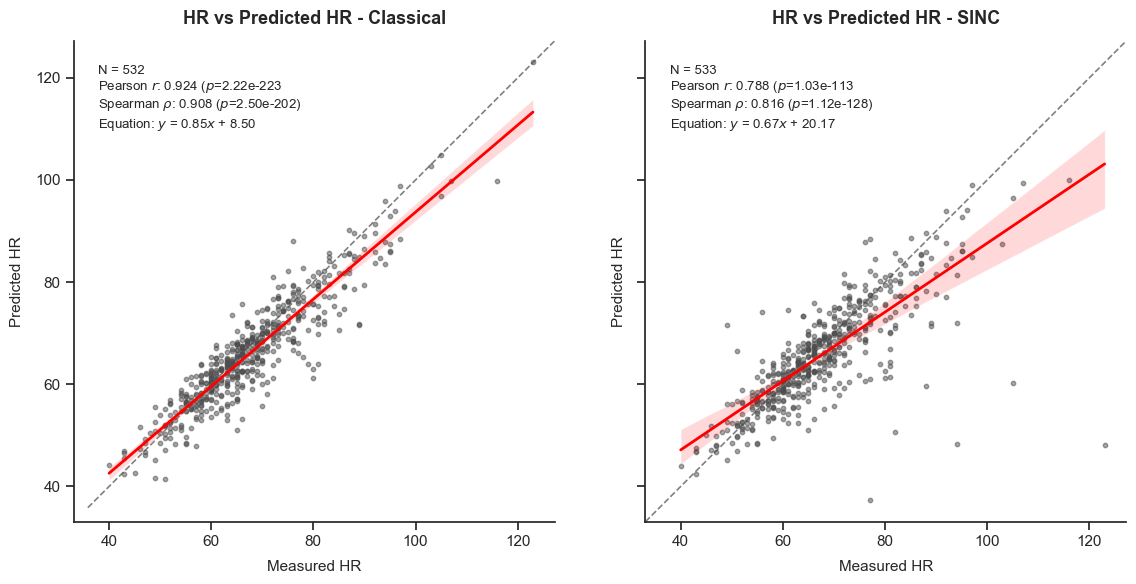

In [2]:
# | label: fig-sinc-vs-traditional-hr
# | echo: false
# | warn: false

from ocularrigidity.stats.plot import regression_plot_with_stats

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 6), sharey=True, sharex=True)

regression_plot_with_stats(
    classical_df,
    x="HR",
    y="predicted_HR",
    xlabel="Measured HR",
    ylabel="Predicted HR",
    title="HR vs Predicted HR - Classical",
    ax=axes[0],
    print_stats=False,
)
regression_plot_with_stats(
    sinc_df,
    x="HR",
    y="predicted_HR",
    xlabel="Measured HR",
    ylabel="Predicted HR",
    title="HR vs Predicted HR - SINC",
    ax=axes[1],
    print_stats=False,
)

/tmp/ipykernel_1188534/3700238617.py:48: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(["Classical", "SINC"])


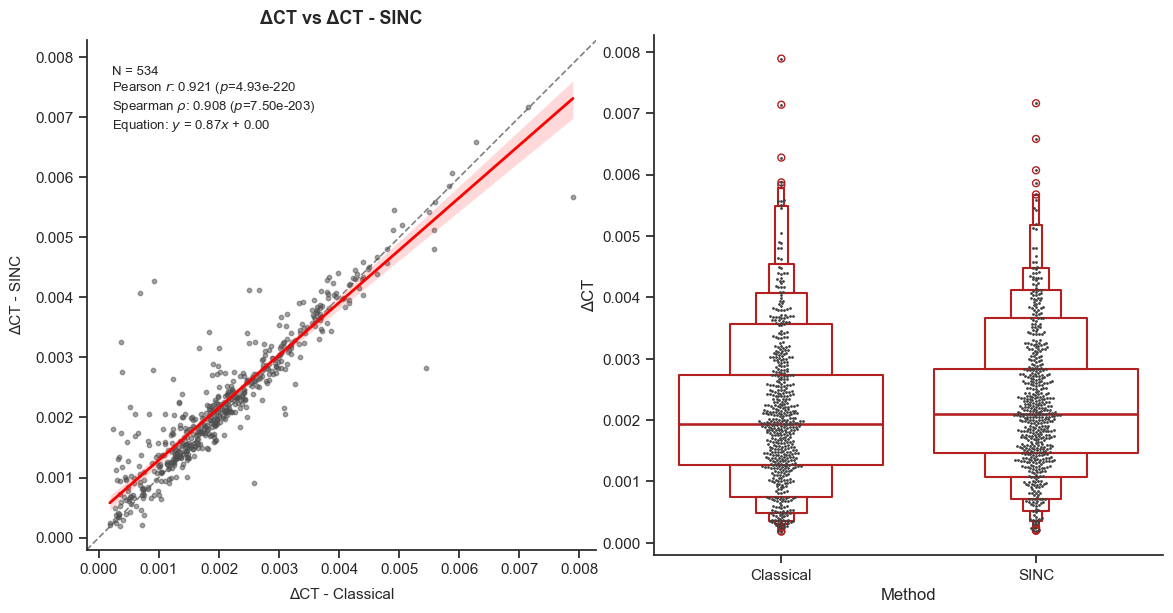

In [3]:
# | label: fig-sinc-vs-traditional-deltaCT
# | echo: false
# | warn: false
import seaborn as sns

merged_deltaCT = pd.merge(
    sinc_df[["deltaCT"]],
    classical_df[["deltaCT"]],
    left_index=True,
    right_index=True,
    suffixes=("_sinc", "_classical"),
)
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))
regression_plot_with_stats(
    merged_deltaCT,
    x="deltaCT_classical",
    y="deltaCT_sinc",
    xlabel="ΔCT - Classical",
    ylabel="ΔCT - SINC",
    title="ΔCT vs ΔCT - SINC",
    print_stats=False,
    ax=axes[0],
)
long_df = pd.melt(
    merged_deltaCT.reset_index(),
    value_vars=["deltaCT_classical", "deltaCT_sinc"],
    var_name="Method",
    value_name="ΔCT",
)

sns.boxenplot(
    data=long_df,
    x="Method",
    y="ΔCT",
    ax=axes[1],
    fill=False,
    color="#b41f1f",
)
sns.swarmplot(
    data=long_df,
    x="Method",
    y="ΔCT",
    color=".25",
    ax=axes[1],
    size=2,
)
# Set the x-axis labels to be more readable
axes[1].set_xticklabels(["Classical", "SINC"])
plt.show()

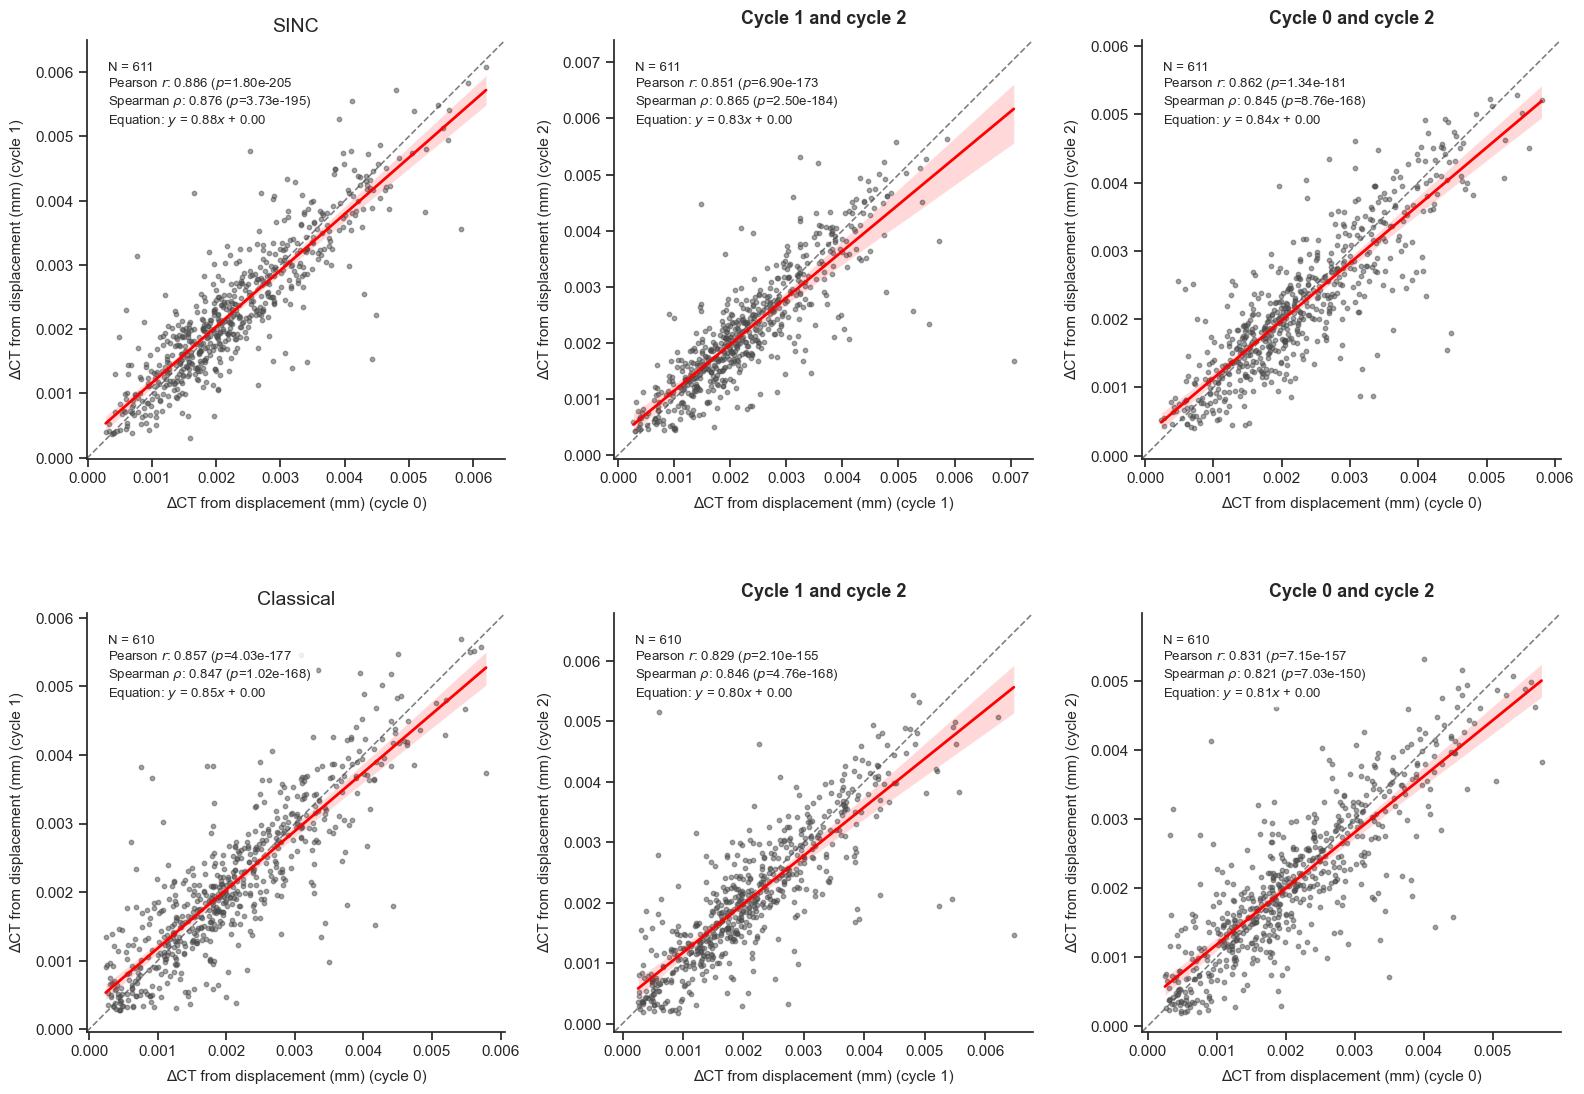

In [4]:
# | label: fig-sinc-vs-traditional-deltaCT-cycles
# | echo: false
# | warn: false
# | fig-cap: "Comparison of ΔCT between cycles for SINC and the classical method."
from ocularrigidity.stats.plot import regression_plot_with_stats


comparisons_cycles = [(0, 1), (1, 2), (0, 2)]
variables = [
    ("deltaCT", "ΔCT from displacement (mm)"),
]
fig, axes = plt.subplots(nrows=2, ncols=len(comparisons_cycles), figsize=(16, 16))
for i, (cycle_label, cycles) in enumerate(
    zip(["SINC", "Classical"], [sinc_cycles, classical_cycles])
):
    for var, label in variables:
        for j, (c1, c2) in enumerate(comparisons_cycles):
            ax = axes[i, j]
            cases_x = cycles[cycles.cycle == c1]
            cases_y = cycles[cycles.cycle == c2]
            # Merge the two dataframes on the "Case" column to ensure we only compare cases that exist in both cycles
            cases_x = cases_x.set_index("video")
            cases_y = cases_y.set_index("video")
            merged = cases_x.join(
                cases_y, lsuffix=f"_cycle{c1}", rsuffix=f"_cycle{c2}", how="inner"
            )
            regression_plot_with_stats(
                merged,
                x=f"{var}_cycle{c1}",
                y=f"{var}_cycle{c2}",
                ax=ax,
                xlabel=f"{label} (cycle {c1})",
                ylabel=f"{label} (cycle {c2})",
                title=f"Cycle {c1} and cycle {c2}",
                drop_outlier_quantile=0.99,
                print_stats=False,
            )
            # Put a title for the row
            if j == 0:
                ax.set_title(f"{cycle_label}", fontsize=14)
plt.tight_layout()
plt.show()

In [5]:
sinc_cycles

,video,cycle,deltaCT,deltaCT_Mask,deltaCT_MaskThickness,minCT,RelativeGrowth,thickening_um_s,thinning_um_s,rate_asymmetry,thickening_fraction
0,1242919/2023-04-20/Rigidity/OD,0,0.001980,0.010132,0.003141,0.399092,0.004962,6.355571,12.420987,0.511680,0.600000
1,1242919/2023-04-20/Rigidity/OD,1,0.001376,0.016444,0.004589,0.397464,0.003462,11.816394,14.927449,0.791588,0.500000
2,1242919/2023-04-20/Rigidity/OD,2,0.001846,0.009040,0.002762,0.399560,0.004620,8.104515,7.715711,1.050391,0.500000
3,1986980/2022-12-01/Rigidity/OS,0,0.002034,0.007400,0.002578,0.419480,0.004849,5.135997,6.212470,0.826724,0.500000
4,1986980/2022-12-01/Rigidity/OS,1,0.001071,0.008135,0.002063,0.418833,0.002558,3.481563,5.570708,0.624977,0.533333
...,...,...,...,...,...,...,...,...,...,...,...
1933,b071684/2023-01-11/Rigidity/OD3,1,0.001651,0.006881,0.006833,0.247849,0.006662,7.175664,6.916283,1.037503,0.466667
1934,b071684/2023-01-11/Rigidity/OD3,2,0.001228,0.016918,0.002216,0.242607,0.005061,7.250959,6.957598,1.042164,0.466667
1935,b071684/2024-02-08/Rigidity/OD,0,0.002700,0.009058,0.002729,0.215815,0.012511,8.286112,8.980108,0.922719,0.500000
1936,b071684/2024-02-08/Rigidity/OD,1,0.002522,0.008769,0.004170,0.219864,0.011470,11.339518,10.655446,1.064199,0.466667
